In [1]:
!pip install gensim matplotlib scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 59.3 MB/s eta 0:00:00


In [2]:
from gensim.models import Word2Vec
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

In [3]:
# Tokenized sentences (toy dataset for demonstration)
sentences = [
    ["king", "queen", "man", "woman"],
    ["apple", "orange", "fruit"],
    ["car", "bus", "vehicle"],
    ["paris", "france", "london", "england"],
    ["dog", "cat", "animal"],
    ["teacher", "student", "school"],
    ["python", "java", "programming"],
    ["sun", "moon", "sky"]
]

In [4]:
model = Word2Vec(
    sentences,
    vector_size=100,   # size of word vectors
    window=3,          # context window
    min_count=1,       # include all words
    sg=1               # 1 = Skip-gram, 0 = CBOW
)

In [5]:
print("Vector for 'king':\n", model.wv['king'])

Vector for 'king':
 [ 0.00964853  0.00732483  0.00126166 -0.00340524 -0.00045066  0.00042262
 -0.00640921  0.00574516  0.0023714   0.00377794 -0.00725502  0.00852629
  0.00050825 -0.00020393 -0.00907161  0.00404876  0.00676344  0.00735509
 -0.00641753 -0.00785606 -0.00552371 -0.0006029  -0.00833798 -0.00824012
 -0.00191757  0.00113929 -0.00950655 -0.00373293  0.00064478  0.00680997
  0.00173499 -0.00063238 -0.00748139 -0.00674209 -0.00069443  0.00746758
  0.00544287 -0.00148269  0.00117231 -0.00960578 -0.0013845  -0.00462622
  0.00580931 -0.00233801 -0.00476407 -0.00947511 -0.00120031 -0.00719777
 -0.00168522 -0.00406982 -0.00237414 -0.00324834 -0.00815647 -0.00124841
  0.00169094 -0.00404764 -0.00764145 -0.00358664 -0.00904713 -0.00075842
  0.005883   -0.00296135  0.00316176  0.00499572  0.00846843  0.00562142
  0.00950855 -0.00964668 -0.00796267 -0.00675816 -0.00746771 -0.00796362
 -0.00778817 -0.00294263  0.00139616 -0.00287479 -0.00881625  0.00498586
  0.00090089  0.0045904   0.007

In [6]:
print("Words similar to 'king':")
print(model.wv.most_similar('king'))

Words similar to 'king':
[('apple', 0.21655213832855225), ('school', 0.16265207529067993), ('london', 0.149579718708992), ('fruit', 0.12766698002815247), ('woman', 0.07537200301885605), ('dog', 0.04024103656411171), ('france', 0.036913156509399414), ('england', 0.03130390867590904), ('java', 0.019886517897248268), ('sun', 0.013395113870501518)]


In [7]:
print("king - man + woman = ?")
print(model.wv.most_similar(positive=['king', 'woman'], negative=['man']))

king - man + woman = ?
[('fruit', 0.13429848849773407), ('orange', 0.11225651949644089), ('apple', 0.07420767843723297), ('dog', 0.06476322561502457), ('school', 0.04846576601266861), ('java', 0.029368657618761063), ('london', 0.028037093579769135), ('bus', 0.016882067546248436), ('animal', 0.0019220279064029455), ('sun', 0.0010076849721372128)]


In [9]:
# Get all words
words = list(model.wv.index_to_key)

# Get vectors
vectors = model.wv[words]

# Reduce dimensions
tsne = TSNE(n_components=2, random_state=42, perplexity=5)
reduced_vectors = tsne.fit_transform(vectors)

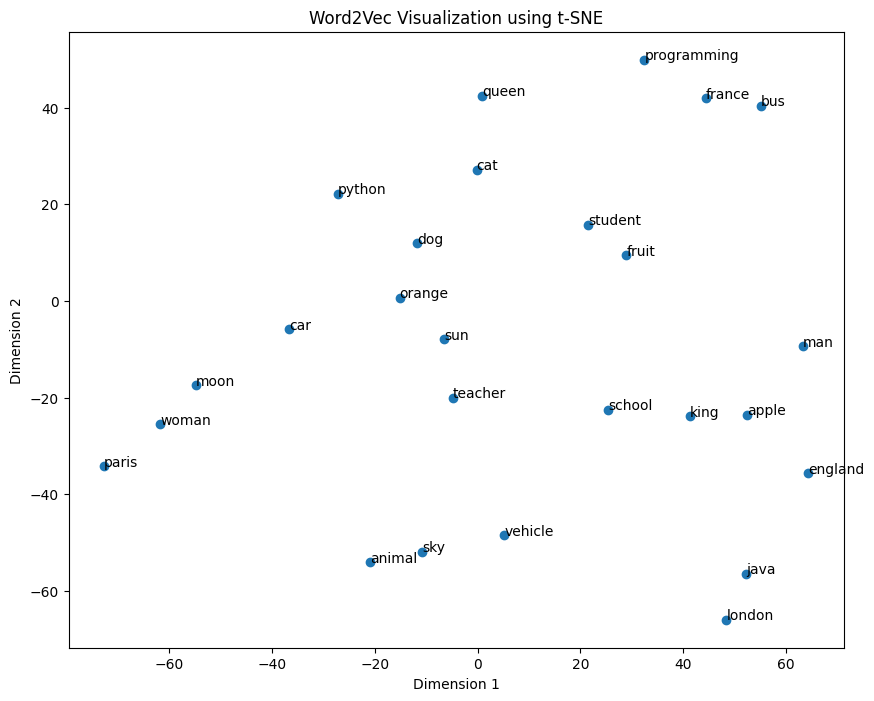

In [10]:
plt.figure(figsize=(10, 8))
plt.scatter(reduced_vectors[:, 0], reduced_vectors[:, 1])

# Annotate points
for i, word in enumerate(words):
    plt.annotate(word, (reduced_vectors[i, 0], reduced_vectors[i, 1]))

plt.title("Word2Vec Visualization using t-SNE")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.show()